Investigating the role of autapses in bursting activity.

In [1]:
"""
OLD FILE - IGNORE


Take autapse params from Yin et al. 2018 and Pan et al. for excitatory autapse

Yin et al. 2018: f ~ 150 pA [27-430pA]
                 decay time constant = 4.6 ms
                 => e ~ 0.217
                 onset time 2ms, rise time 1ms 
                 => tau ~ 2-3ms?

Pan et al. 2025: f ~ 130 +- 16 pA
                 e ~ 0.182 +- 0.2 Hz

                
For inhibitory autapse see Deleuze et al. 2019 (PV interneurons), Bacci & Huguenard 2003
                 f ~ -451 +- 43
                 e ~ 0.27 +- 0.1
Bacci et al. 2003:
                 f ~ -352 +- 71 pA
                 e ~ 0.14 +- 0.03 Hz
                 latency ~ 1.76 +- 0.07 ms; rise time ~ 0.56 ms
                 tau ~ 2 ms
"""

'\nOLD FILE - IGNORE\n\n\nTake autapse params from Yin et al. 2018 and Pan et al. for excitatory autapse\n\nYin et al. 2018: f ~ 150 pA [27-430pA]\n                 decay time constant = 4.6 ms\n                 => e ~ 0.217\n                 onset time 2ms, rise time 1ms \n                 => tau ~ 2-3ms?\n\nPan et al. 2025: f ~ 130 +- 16 pA\n                 e ~ 0.182 +- 0.2 Hz\n\n\nFor inhibitory autapse see Deleuze et al. 2019 (PV interneurons), Bacci & Huguenard 2003\n                 f ~ -451 +- 43\n                 e ~ 0.27 +- 0.1\nBacci et al. 2003:\n                 f ~ -352 +- 71 pA\n                 e ~ 0.14 +- 0.03 Hz\n                 latency ~ 1.76 +- 0.07 ms; rise time ~ 0.56 ms\n                 tau ~ 2 ms\n'

In [2]:
import sys
sys.path.append("../") # parent directory
from AQUA_general import AQUA
from batchAQUA_general import batchAQUA
from stimulus import *
from plotting_functions import *
from phase_response import *


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Excitatory Autapse on a model Pyramidal Neuron

In [4]:
# regular spiking neuron
RS_int = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.0, 'f': 0.0, 'tau': 0.0}

RS_res = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0.0, 'f': 0.0, 'tau': 0.0}

T = 2  #ms
dt = 0.01 # ms
N_iter = int(1000*T/dt)

x_ini = np.array([-80, 0, 0])
t_ini = 0.0

N_neurons = 200
I_range = np.linspace(0, 700, N_neurons)

#define initial conditions
params_int = []
params_res = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for n in range(N_neurons):
    params_int.append(RS_int)
    params_res.append(RS_res)
    x_start[n, :] = x_ini
    t_start[n] = t_ini


I_inj = np.array([i*np.ones(N_iter) for i in I_range])
print(np.shape(I_inj))

batch_int = batchAQUA(params_int)
batch_int.Initialise(x_start, t_start)
X_int, _, spikes_int = batch_int.update_batch(dt, N_iter, I_inj)

batch_res = batchAQUA(params_res)
batch_res.Initialise(x_start, t_start)
X_res, _, spikes_res = batch_res.update_batch(dt, N_iter, I_inj)

(200, 200000)


100%|██████████| 199999/199999 [00:29<00:00, 6694.64it/s]


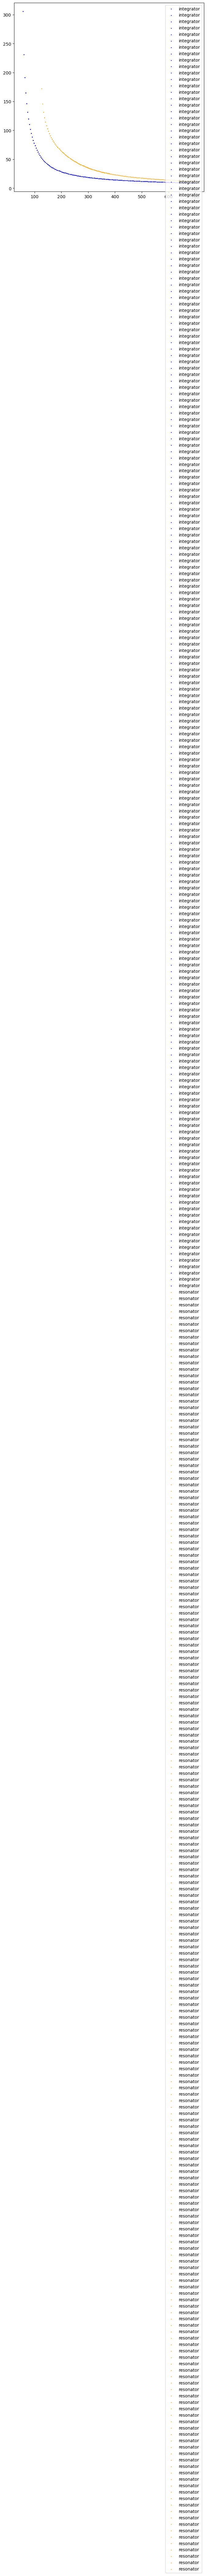

In [ ]:
# plot the bifurcation diagram
fig, ax = plt.subplots(1, 1, figsize = (8, 8))
fig, ax = plot_bifurcation_I(spikes_int, I_range, steady_state = True, fig = fig, ax = ax)
fig, ax = plot_bifurcation_I(spikes_res, I_range, steady_state = True, fig = fig, ax = ax)
#plt.savefig(".\\bifurcations_I\\pyr_naut_steady.png")
plt.legend()
plt.show()

In [6]:
# regular spiking neuron
# autapse params described in intro.
RS_a = {'name': 'RS_a', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 150.0, 'tau': 2.0}


#define initial conditions
params = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for n in range(N_neurons):
    params.append(RS_a)
    x_start[n, :] = x_ini
    t_start[n] = t_ini


I_inj = np.array([i*np.ones(N_iter) for i in I_range])
print(np.shape(I_inj))

batch = batchAQUA(params)

batch.Initialise(x_start, t_start)

X_a, _, spikes_ea = batch.update_batch(dt, N_iter, I_inj)

(200, 200000)


100%|██████████| 199999/199999 [00:29<00:00, 6716.85it/s]


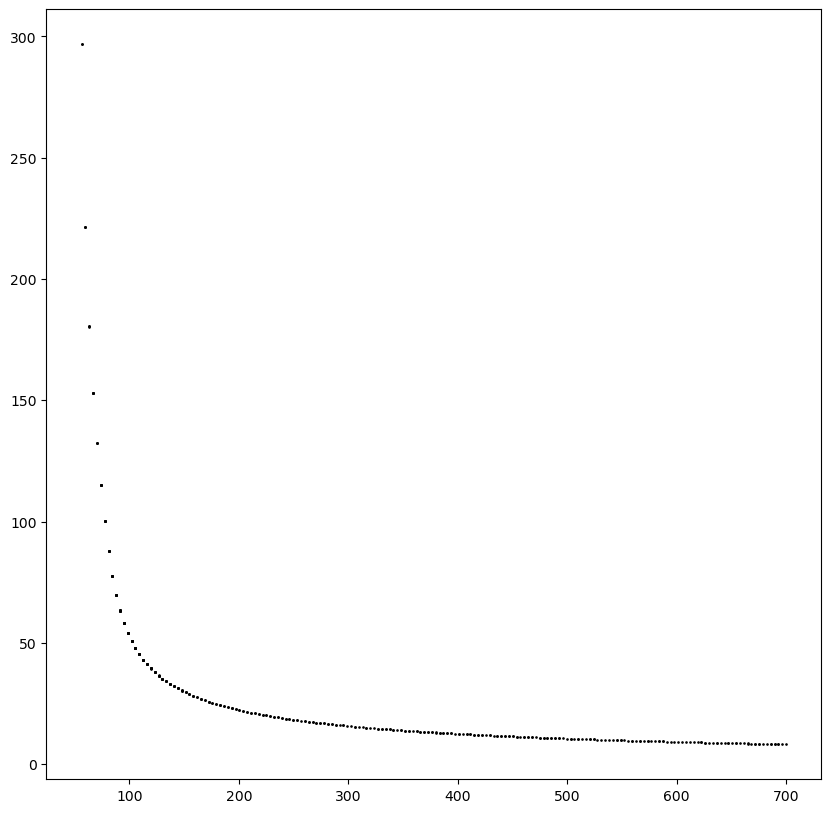

In [7]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_I(spikes_ea, I_range, steady_state = True)
plt.savefig(".\\bifurcations_I\\pyr_aut_steady.png")
plt.show()

In [8]:
# plot the bifurcation diagram of instantaneous ISIs from normal neuron
fig, ax = plot_bifurcation_I(spikes_e, I_range, steady_state = False)
plt.savefig(".\\bifurcations_I\\pyr_naut_instant.png")
plt.show()

NameError: name 'spikes_e' is not defined

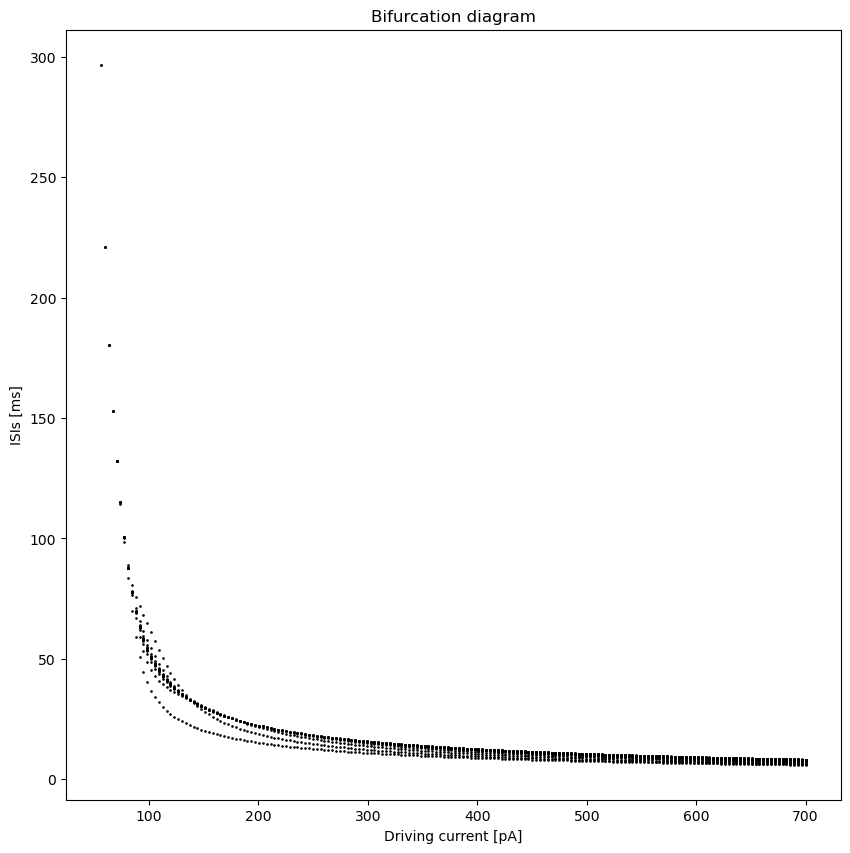

In [ ]:
# plot the bifurcation diagram of instantaneous ISIs from autaptic neuron
fig, ax = plot_bifurcation_I(spikes_ea, I_range, steady_state = False)
plt.savefig(".\\bifurcations_I\\pyr_aut_instant.png")
plt.show()

281.4070351758794


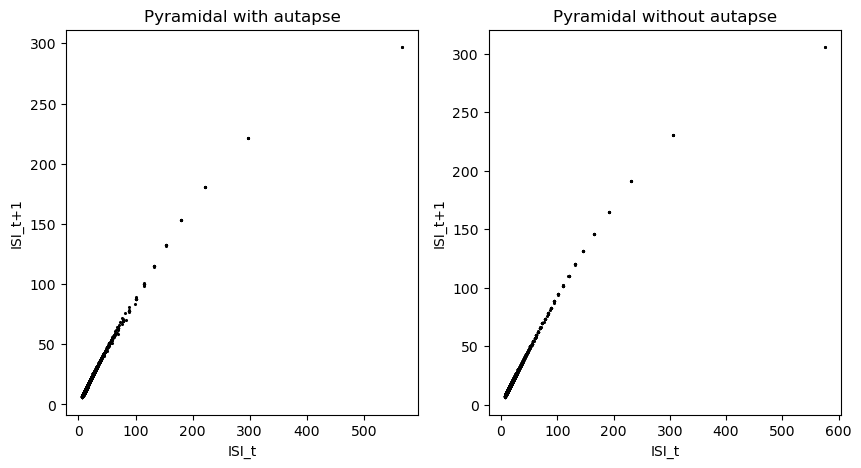

In [ ]:
num = 80
print(I_range[num])
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
fig, ax[0] = first_return(spikes_ea, fig, ax[0])
fig, ax[1] = first_return(spikes_e, fig, ax[1])

ax[0].set_title("Pyramidal with autapse")
ax[1].set_title("Pyramidal without autapse")
plt.show()

Initial results show that the autapse on the excitatory neuron model has little effect on the long-term activity of the neuron. However, there is a noticeable complication of the instantaneous activity

### Inhibitory Autapse on a model Fast-spiking interneuron

In [ ]:
# fast-spiking interneuron
FS = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.0, 'f': 0.0, 'tau': 0.0}


#define initial conditions
params = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for n in range(N_neurons):
    params.append(FS)
    x_start[n, :] = x_ini
    t_start[n] = t_ini


I_inj = np.array([i*np.ones(N_iter) for i in I_range])
print(np.shape(I_inj))

batch = batchAQUA(params)

batch.Initialise(x_start, t_start)

X, _, spikes_i = batch.update_batch(dt, N_iter, I_inj)

(200, 200000)


100%|██████████| 199999/199999 [00:44<00:00, 4522.34it/s]


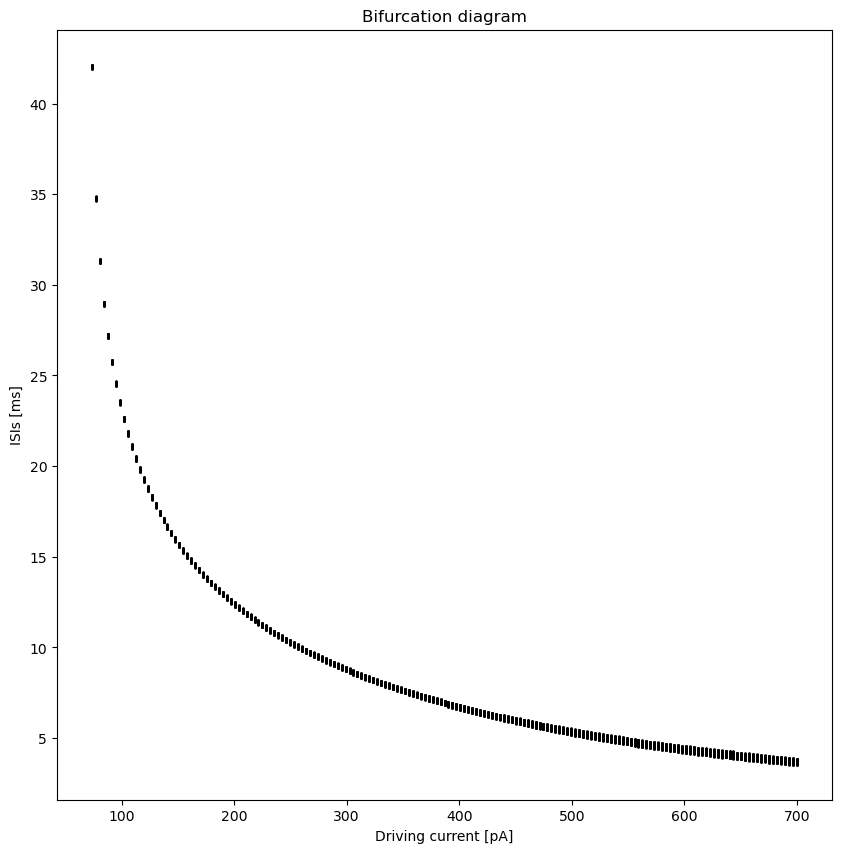

In [ ]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_I(spikes_i, I_range, steady_state = True)
plt.savefig(".\\bifurcations_I\\fs_naut_steady.png")
plt.show()

In [ ]:
# fast-spiking interneuron
# autapse from Bacci 2003
FS_a = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.14, 'f': -350.0, 'tau': 2.0}


#define initial conditions
params = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for n in range(N_neurons):
    params.append(FS_a)
    x_start[n, :] = x_ini
    t_start[n] = t_ini


I_inj = np.array([i*np.ones(N_iter) for i in I_range])
print(np.shape(I_inj))

batch = batchAQUA(params)

batch.Initialise(x_start, t_start)

X, T, spikes_ia = batch.update_batch(dt, N_iter, I_inj)

(200, 200000)


100%|██████████| 199999/199999 [00:45<00:00, 4438.26it/s]


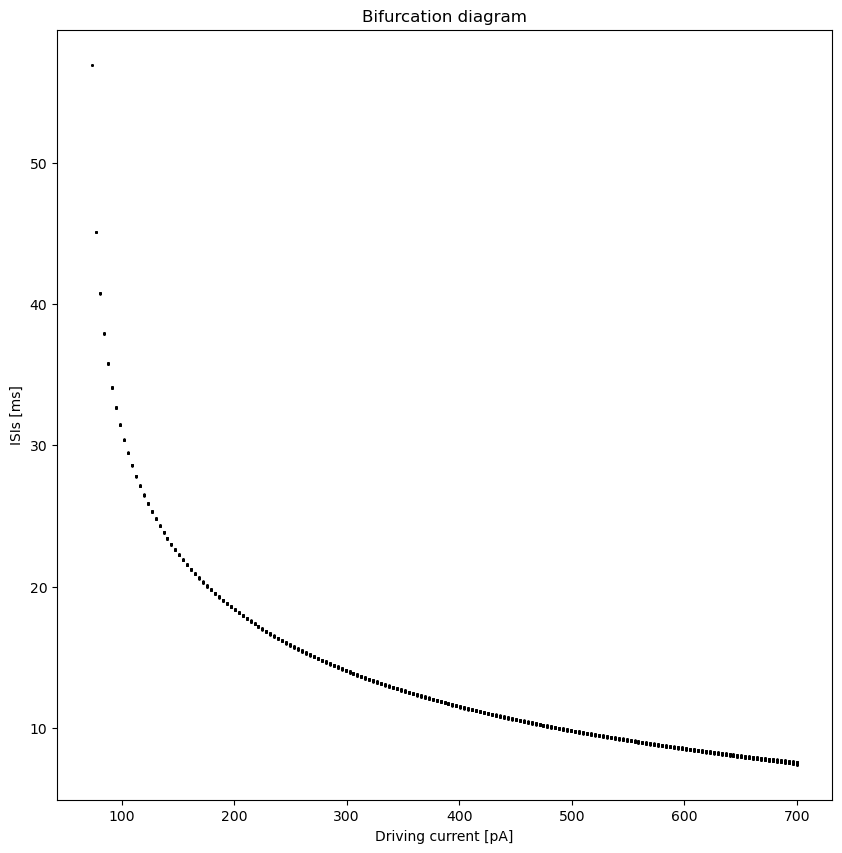

In [ ]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_I(spikes_ia, I_range, steady_state = True)
plt.savefig(".\\bifurcations_I\\fs_aut_steady.png")
plt.show()

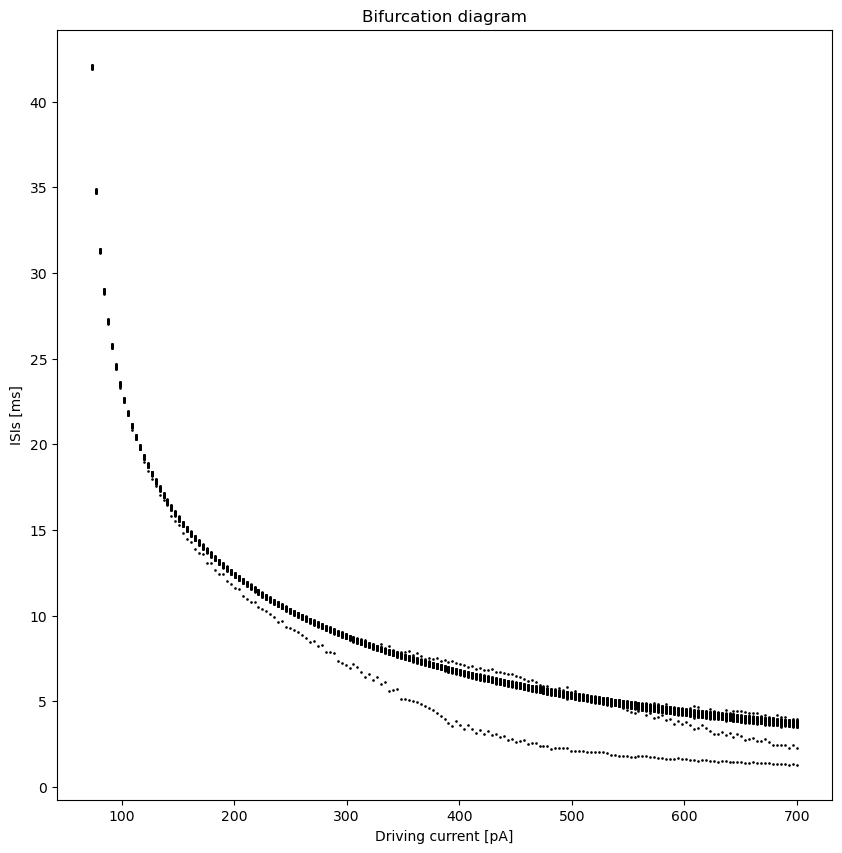

In [ ]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_I(spikes_i, I_range, steady_state = False)
plt.savefig(".\\bifurcations_I\\fs_naut_instant.png")
plt.show()

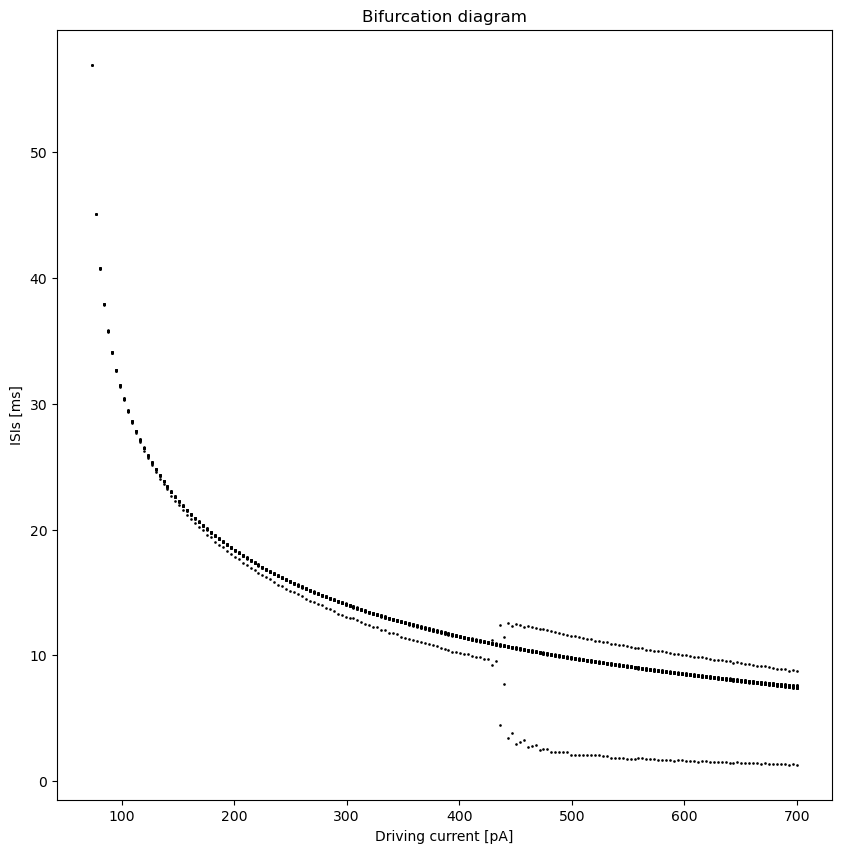

In [ ]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_I(spikes_ia, I_range, steady_state = False)
plt.savefig(".\\bifurcations_I\\fs_aut_instant.png")
plt.show()

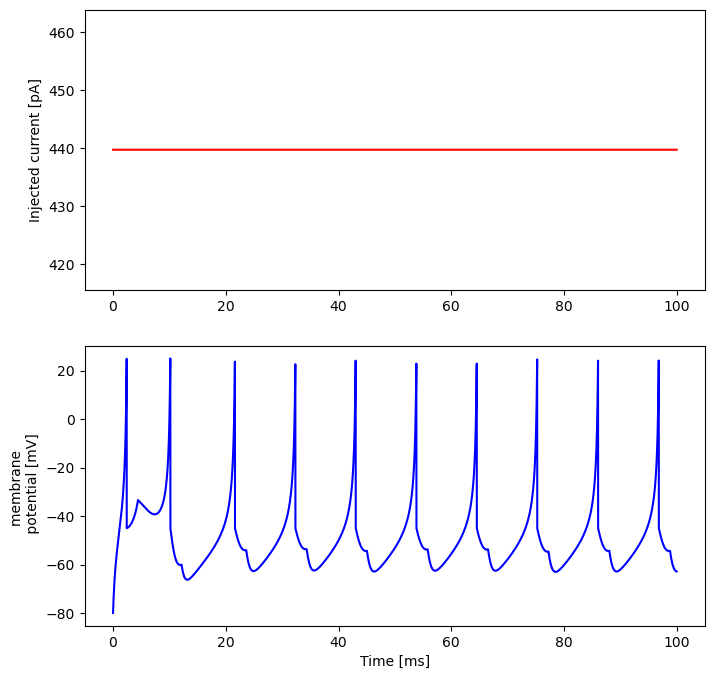

In [ ]:
# plot the membrane potential for one of the inhibitory neuron spike trains
fig, ax = plot_potential_versus_injected(X[-75, :], T[:], I_inj[-75, :], split = range(10000))
plt.show()

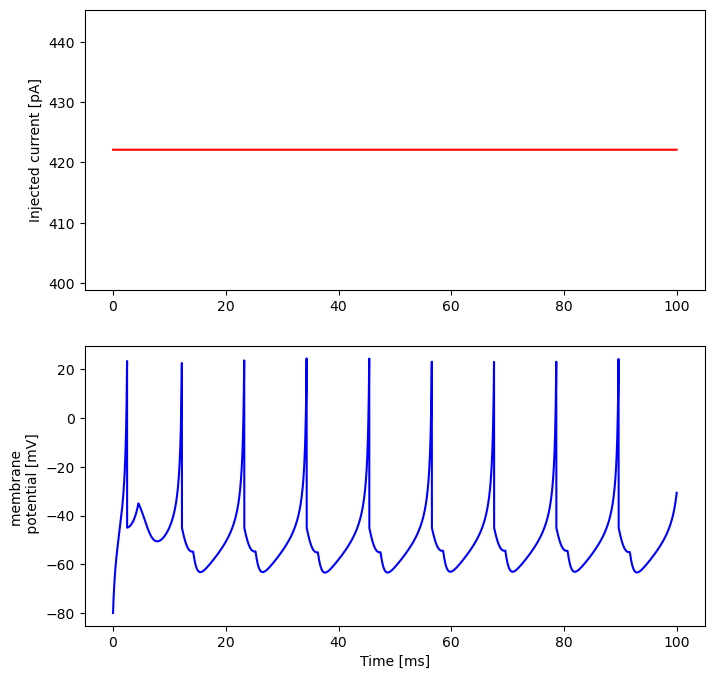

In [ ]:
# plot the membrane potential for one of the inhibitory neuron spike trains
fig, ax = plot_potential_versus_injected(X[-80, :], T[:], I_inj[-80, :], split = range(10000))
plt.show()

70.35175879396985


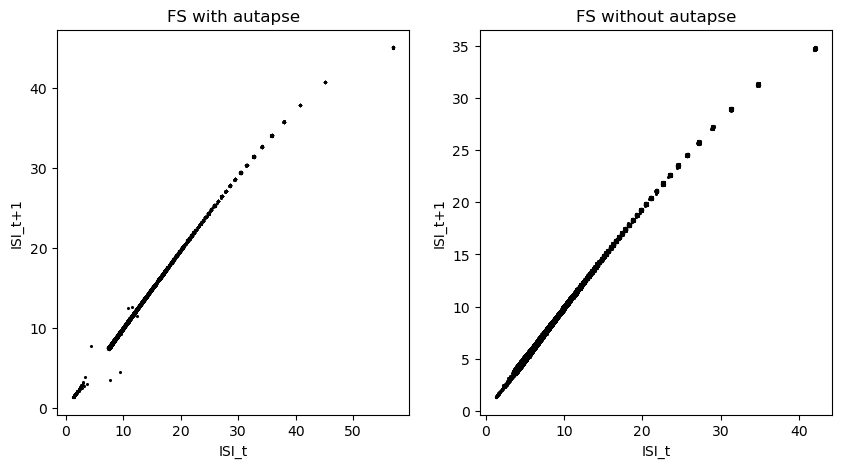

In [ ]:
num = 20
print(I_range[20])
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
fig, ax[0] = first_return(spikes_ia, fig, ax[0])
fig, ax[1] = first_return(spikes_i, fig, ax[1])

ax[0].set_title("FS with autapse")
ax[1].set_title("FS without autapse")
plt.show()